# From Willow to Quandela — CPSR / ID-QND-RC on Photonic DVQC (Perceval)

**Topology-optimised Critical-Phase Shadow Reservoir** ported to Quandela's single-photon,
linear-optical processors (Belenos / Canopus), programmed in **Perceval**.

This notebook implements the recommended **Route C (hybrid)** from your migration plan:

* **Route B** native *boson-sampling reservoir* for the processing core — a tunable
  linear-optical mesh on `2N` modes; the "edge of chaos" becomes the scrambling of the
  mesh, tuned by a global mixing angle `g` (or `~(2N)²` independent phases).
* **Photon-count classical shadows** as the feature map (`⟨nᵢ⟩`, `⟨nᵢnⱼ⟩`) so the QPU
  leaves the inference path — a classical head trains once and predicts with zero QPU time.
* **Route C classical/QELM memory** (a classical time-delay window feeding the photonic
  feature map) so the whole thing **runs on Belenos today**, with honest notes on where the
  *quantum* memory (SPOQC spin / optical delay-loop) would replace it.

**Encoding:** one logical qubit = one photon in two modes (dual-rail): `|0⟩_L=|1,0⟩`,
`|1⟩_L=|0,1⟩`. `N` qubits → `N` photons in `2N` modes.

> The notebook runs fully in local simulation (`SLOS`). The final section swaps to real
> hardware by changing **one object** to `pcvl.RemoteProcessor('qpu:belenos', token)`.
> Verified against **Perceval 1.2.x**. Treat platform names / noise figures as
> version-dependent and re-confirm against your Quandela Cloud account.

## 0 · Install & imports

In [1]:
# !pip install --quiet perceval-quandela scikit-learn matplotlib
import numpy as np
import matplotlib.pyplot as plt
from math import comb

import perceval as pcvl
from perceval.components import BS, PS
from perceval.algorithm import Sampler
from sklearn.linear_model import Ridge
from sklearn.neural_network import MLPRegressor

print("Perceval", pcvl.__version__)
rng_global = np.random.RandomState(2026)

Perceval 1.2.4


## 1 · Configuration & dual-rail helpers

`q(i)` returns the two optical modes carrying logical qubit `i`. `default_noise()` encodes
Quandela MosaiQ-like imperfections; on a *photonic* platform the dominant error is **photon
loss** (`transmittance`), not `T1/T2`. Valid-event yield scales like `η^N`, so plan `N ≤ 12`
for near-term Belenos hardware and use simulation for larger trends.

In [2]:
N        = 3                 # logical qubits  -> N photons in 2N modes
BACKEND  = "SLOS"            # exact local simulator while prototyping
N_SAMPLES = 40_000           # raw samples per reservoir call (raise for lower shadow noise)

def q(i):
    "logical qubit i  <->  optical modes (2i, 2i+1);  |0>_L=|1,0>, |1>_L=|0,1>"
    return (2 * i, 2 * i + 1)

def default_noise():
    "Belenos-like source imperfections (re-confirm at run time)."
    return pcvl.NoiseModel(brightness=0.93, g2=0.01,
                           indistinguishability=0.94, transmittance=0.90)

# fixed reservoir disorder (drawn once; the reservoir is NON-trainable)
_res_rng = np.random.RandomState(42)
SIGMA = _res_rng.uniform(0.3, 0.7, N)      # input-scaling per qubit
BETA  = _res_rng.uniform(0.0, 2*np.pi, N)  # fixed R_z disorder phases
print("sigma =", np.round(SIGMA, 3), "\nbeta  =", np.round(BETA, 3))

sigma = [0.45  0.68  0.593] 
beta  = [3.761 0.98  0.98 ]


## 2 · Reservoir circuit — Part 1 (edge of chaos & topology)

Single-qubit layers (input `R_y(π·u·σ)` + fixed disorder `R_z(β)`) are near-perfect passive
optics. The **entangling** layer is *not* a logical CZ — on linear optics photons don't
interact — so `g` instead sets the **mode-mixing beam-splitter angle** that generates
photon-number correlation between adjacent dual-rail pairs. `g=0` → disconnected (no mixing);
`g=π/2` → maximal scrambling. The four CPSR topologies become beam-splitter placement
patterns; because the mesh is reconfigurable there is **no SWAP-routing cost**.

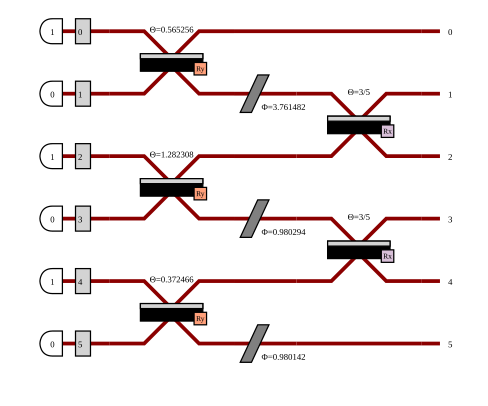

In [3]:
def critical_mesh_edges(N, topology):
    return {
        'disconnected': [],
        'chain':  [(k, k+1) for k in range(N-1)],
        'zigzag': [(k, k+1) for k in range(0, N-1, 2)] +
                  [(k, k+1) for k in range(1, N-1, 2)],
        'ladder': [(k, k+1) for k in range(N-1)] +
                  [(k, k+2) for k in range(N-2)],
    }[topology]

def add_input_and_disorder(proc, N, window, sigma, beta):
    "Deterministic single-qubit layer: R_y(pi*u*sigma) input + R_z(beta) disorder."
    for k in range(N):
        u = window[k] if k < len(window) else 0.0
        proc.add(2*k,     BS.Ry(theta=np.pi * u * sigma[k]))   # input encoding
        proc.add(2*k + 1, PS(phi=beta[k]))                     # dual-rail Rz phase

def add_entangling(proc, N, g, topology):
    "Mode-mixing BSs (strength g) between lower rail of a and upper rail of b."
    for (a, b) in critical_mesh_edges(N, topology):
        proc.add((2*a + 1, 2*b), BS(theta=2*g))

def mesh_with_G_knobs(N, g_vector):
    "Programmable Clements-style mesh: every BS its own angle (~(2N)^2 'g' knobs)."
    c = pcvl.Circuit(2*N)
    k = 0
    for layer in range(2*N):
        for mode in range(layer % 2, 2*N - 1, 2):
            c.add(mode, BS(theta=g_vector[k % len(g_vector)])); k += 1
    return c

def build_reservoir(N, window, sigma, beta, g, topology='chain',
                    noise=None, g_vector=None, backend=BACKEND):
    "Assemble one photonic reservoir Processor for an input window."
    proc = pcvl.Processor(backend, 2*N, noise=noise)
    add_input_and_disorder(proc, N, window, sigma, beta)
    if g_vector is not None:
        proc.add(0, mesh_with_G_knobs(N, g_vector))            # programmable mesh
    else:
        add_entangling(proc, N, g, topology)                   # topology + single g
    proc.min_detected_photons_filter(N)                        # keep valid N-photon events
    proc.with_input(pcvl.BasicState([1, 0] * N))               # all qubits |0>_L
    return proc

def sample_counts(proc, n_samples=N_SAMPLES):
    return Sampler(proc).sample_count(int(n_samples))['results']

# quick visual of one reservoir circuit
demo = build_reservoir(N, [0.4, 0.6, 0.2], SIGMA, BETA, g=0.3, topology='chain')
pcvl.pdisplay(demo, recursive=True)

## 3 · Feature maps from detection statistics — Part 2 (classical shadows)

A real photonic QPU is **sampling-only**, so we estimate every feature from clicks — exactly
the classical-shadow workflow. Two options:

* **Photon-count shadows (Route B):** `⟨nᵢ⟩` and `⟨nᵢnⱼ⟩` over all `2N` modes — the natural
  bosonic features; no post-selection needed.
* **Dual-rail Pauli shadows (Route A/C):** post-select one photon per pair, then form the
  Huang–Kueng–Preskill 1-/2-body estimators (needs a basis-rotation run per Pauli).

In [4]:
def dual_rail_valid(fock_list, N):
    "A valid dual-rail readout has exactly one photon per qubit pair."
    return all(fock_list[2*k] + fock_list[2*k+1] == 1 for k in range(N))

def photon_count_features(counts, N, max_weight=2):
    "Bosonic shadows: <n_i>, <n_i n_j> over ALL 2N modes."
    M = 2*N
    tot = sum(counts.values())
    if tot == 0:
        return np.zeros(M + comb(M, 2))
    n1 = np.zeros(M); n2 = np.zeros((M, M))
    for fs, c in counts.items():
        v = np.array(list(fs), dtype=float); w = c / tot
        n1 += w * v
        if max_weight >= 2:
            n2 += w * np.outer(v, v)
    feats = [n1]
    if max_weight >= 2:
        feats.append(n2[np.triu_indices(M, k=1)])
    return np.concatenate(feats)

def dual_rail_pauli_features(counts_by_basis, N):
    "HKP-style 1-body Z/X/Y expectations from post-selected dual-rail patterns."
    labels, feats = [], []
    for basis in ['Z', 'X', 'Y']:
        counts = counts_by_basis.get(basis)
        if counts is None:
            continue
        valid = {fs: c for fs, c in counts.items() if dual_rail_valid(list(fs), N)}
        tot = sum(valid.values()) or 1
        ev = np.zeros(N)
        for fs, c in valid.items():
            fl = list(fs)
            bits = np.array([fl[2*k+1] for k in range(N)])   # 1 => |1>_L
            ev += (c/tot) * (1 - 2*bits)
        labels += [f'{basis}{k}' for k in range(N)]; feats += list(ev)
    return labels, np.array(feats)

# feature dimension for the current N
_f = photon_count_features(sample_counts(demo, 5000), N)
print(f"photon-count feature vector length = {len(_f)}  (= 2N + C(2N,2))")

photon-count feature vector length = 21  (= 2N + C(2N,2))


## 4 · Benchmark tasks, readout heads & metrics (unchanged classical code)

The tasks, ridge/MLP heads and NRMSE / memory-capacity metrics are the **same classical
code** as your Willow repo — only the *features* now come from photons.

In [5]:
def random_input(T, seed=0):  return np.random.RandomState(seed).uniform(0, 1, T)

def task_kpauli(T, k, seed=0):
    u = random_input(T, seed); y = np.zeros(T)
    for t in range(k, T):
        p = 1.0
        for j in range(1, k+1): p *= np.cos(np.pi * u[t-j])
        y[t] = p
    return u, y

def task_narma(T, seed=0):
    u = 0.2*random_input(T, seed); y = np.zeros(T)
    for t in range(1, T-1):
        y[t+1] = 0.3*y[t] + 0.05*y[t]*np.sum(y[max(0,t-9):t+1]) + 1.5*u[t-0]*u[t] + 0.1
    return u, y

def split(T, washout=20, n_test=40, seed=42):
    te = np.arange(T-n_test, T); pool = np.arange(washout, T-n_test)
    np.random.RandomState(seed+7).shuffle(pool); return pool, te

def nrmse_ridge(X, y, alpha=1e-4, washout=20, n_test=40, seed=42):
    pool, te = split(len(y), washout, n_test, seed)
    m = Ridge(alpha=alpha).fit(X[pool], y[pool]); e = m.predict(X[te]) - y[te]
    return float(np.sqrt(np.mean(e**2) / (np.var(y[te]) + 1e-12)))

def nrmse_mlp(X, y, hidden=(64,32), alpha=1e-3, washout=20, n_test=40, seed=42):
    pool, te = split(len(y), washout, n_test, seed)
    m = MLPRegressor(hidden_layer_sizes=hidden, max_iter=500,
                     random_state=seed, alpha=alpha).fit(X[pool], y[pool])
    e = m.predict(X[te]) - y[te]
    return float(np.sqrt(np.mean(e**2) / (np.var(y[te]) + 1e-12)))

def memory_capacity(X, u, k_max=8, alpha=1e-6, washout=20, n_test=40, seed=42):
    T = len(u); pool, te = split(T, washout, n_test, seed); tot, perk = 0.0, []
    for k in range(1, k_max+1):
        tgt = np.zeros(T); tgt[k:] = u[:T-k]
        mdl = Ridge(alpha=alpha).fit(X[pool], tgt[pool]); p = mdl.predict(X[te]); tr = tgt[te]
        c = np.cov(p, tr)[0,1]**2; d = np.var(tr)*np.var(p) + 1e-12
        v = float(min(1.0, c/d)); perk.append(v); tot += v
    return tot, perk

print("tasks + heads ready")

tasks + heads ready


## 5 · Route C — QELM decoupling (classical memory → photonic feature map)

Because a flying photon has **no static register**, memory is offloaded to a classical
time-delay window `[u(t), …, u(t-m)]` that is fed into the photonic nonlinear feature map.
This *runs on Belenos today* and cleanly separates the two reservoir jobs — **memory depth
`m`** (classical dial) vs **nonlinearity** (photonic circuit). Honest caveat: the memory here
is *classical*; the genuinely-quantum memory (SPOQC spin, or an optical delay-loop via
Perceval's `TD` component) would replace this window in Parts 5–6.

In [6]:
def qelm_feature_matrix(u_series, m, N, sigma, beta, g, topology='chain',
                        g_vector=None, noise=None, n_samples=N_SAMPLES):
    "Classical memory window (depth m) -> photonic feature map -> feature matrix."
    feats = []
    for t in range(m, len(u_series)):
        window = u_series[t-N+1:t+1]                     # last N inputs encoded per qubit
        proc = build_reservoir(N, window, sigma, beta, g, topology,
                               noise=noise, g_vector=g_vector)
        feats.append(photon_count_features(sample_counts(proc, n_samples), N))
    return np.array(feats), u_series[m:]

print("QELM feature builder ready")

QELM feature builder ready


## 6 · Experiment 1 — Edge of chaos: scramble vs `g`, and downstream NRMSE

We sweep the global entangling knob `g` and track (i) the **output-distribution entropy**
(a photonic scrambling proxy — it rises toward the Porter–Thomas/Haar plateau) and (ii) the
**downstream test NRMSE** on the k-Pauli task. The hypothesis (identical to Willow): error
bottoms out at an *intermediate* `g`, just past peak scrambling.

*(Small `N`, short series and modest shots keep this cell fast — raise them for publication runs.)*

g/π=0.000  H(out)=1.564  NRMSE=0.173


g/π=0.062  H(out)=1.913  NRMSE=0.194


g/π=0.125  H(out)=2.397  NRMSE=0.197


g/π=0.188  H(out)=2.662  NRMSE=0.237


g/π=0.250  H(out)=2.709  NRMSE=0.176


g/π=0.312  H(out)=2.669  NRMSE=0.209


g/π=0.375  H(out)=2.390  NRMSE=0.178


g/π=0.438  H(out)=1.937  NRMSE=0.196


g/π=0.500  H(out)=1.579  NRMSE=0.180


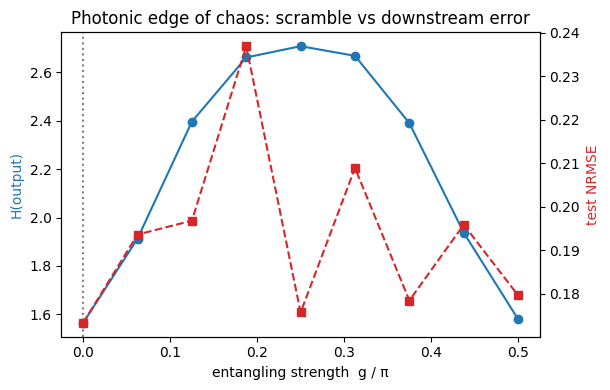

empirical g* = 0.0


In [7]:
def output_entropy(counts):
    tot = sum(counts.values())
    if tot == 0: return 0.0
    p = np.array([c/tot for c in counts.values()]); p = p[p > 0]
    return float(-np.sum(p*np.log(p)))

noise = default_noise()
g_grid = np.linspace(0.0, np.pi/2, 9)
T = 100
u_task, y_task = task_kpauli(T, k=2, seed=7)
m_mem = 2

ent_curve, nrmse_curve = [], []
for g in g_grid:
    # scrambling proxy on a representative single input
    e = output_entropy(sample_counts(
        build_reservoir(N, [0.5]*N, SIGMA, BETA, g, 'chain', noise=noise), 20_000))
    ent_curve.append(e)
    # downstream task NRMSE at this g
    X, y = qelm_feature_matrix(u_task, m_mem, N, SIGMA, BETA, g, 'chain',
                               noise=noise, n_samples=15_000)
    nrmse_curve.append(nrmse_ridge(X, y))
    print(f"g/π={g/np.pi:.3f}  H(out)={e:.3f}  NRMSE={nrmse_curve[-1]:.3f}")

fig, ax1 = plt.subplots(figsize=(6.2, 4))
ax1.plot(g_grid/np.pi, ent_curve, 'o-', color='tab:blue', label='output entropy')
ax1.set_xlabel('entangling strength  g / π'); ax1.set_ylabel('H(output)', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(g_grid/np.pi, nrmse_curve, 's--', color='tab:red', label='NRMSE (k-Pauli)')
ax2.set_ylabel('test NRMSE', color='tab:red')
g_star = g_grid[int(np.argmin(nrmse_curve))]
ax1.axvline(g_star/np.pi, color='gray', ls=':', label=f'g*≈{g_star/np.pi:.2f}π')
plt.title('Photonic edge of chaos: scramble vs downstream error'); fig.tight_layout(); plt.show()
print("empirical g* =", round(float(g_star), 3))

## 7 · Experiment 2 — QRP vs PNR benchmark (does the reservoir help?)

Mirrors Fig. 2 of the Quandela paper: compare the reservoir (`g*`, chain) against the
**PNR benchmark** (`g=0`, disconnected — features from direct detection with no mesh mixing).
The reservoir should match or beat the benchmark once the task needs inter-mode correlation;
raise `N`, mesh depth and shots to widen the gap.

In [8]:
g_use = float(g_star) if 'g_star' in dir() else 0.3

u2, y2 = task_kpauli(120, k=2, seed=11)
Xq, yq = qelm_feature_matrix(u2, m_mem, N, SIGMA, BETA, g_use, 'chain',   noise=noise)
Xp, yp = qelm_feature_matrix(u2, m_mem, N, SIGMA, BETA, 0.0,   'disconnected', noise=noise)

print(f"QRP (g*={g_use:.2f}, chain)      NRMSE = {nrmse_ridge(Xq, yq):.3f}")
print(f"PNR benchmark (g=0, disconnected) NRMSE = {nrmse_ridge(Xp, yp):.3f}")
print(f"QRP with MLP head                 NRMSE = {nrmse_mlp(Xq, yq):.3f}")

QRP (g*=0.00, chain)      NRMSE = 0.163
PNR benchmark (g=0, disconnected) NRMSE = 0.167
QRP with MLP head                 NRMSE = 0.204


## 8 · Experiment 3 — Noise robustness in the Quandela "grid" (Part 4)

Recast entirely in photonic terms: sweep **transmittance loss (1-η)** and **indistinguishability
V**; there is no `T1/T2`. Loss is unforgiving and multiplicative in photon number, so it is the
scaling limiter. We hold the reservoir fixed at `g*` and record the robustness surface.

loss=0.02  V=1.00  NRMSE=0.198


loss=0.02  V=0.94  NRMSE=0.191


loss=0.02  V=0.90  NRMSE=0.198


loss=0.10  V=1.00  NRMSE=0.196


loss=0.10  V=0.94  NRMSE=0.196


loss=0.10  V=0.90  NRMSE=0.199


loss=0.20  V=1.00  NRMSE=0.197


loss=0.20  V=0.94  NRMSE=0.199


loss=0.20  V=0.90  NRMSE=0.194


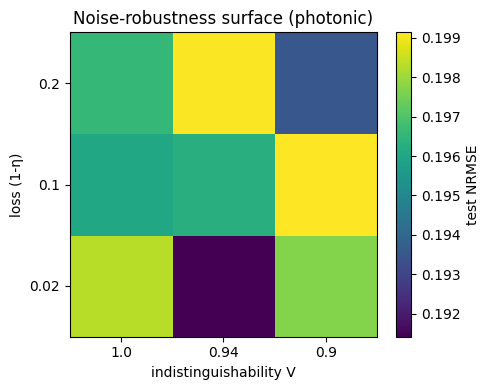

In [9]:
loss_grid = [0.02, 0.10, 0.20]
V_grid    = [1.0, 0.94, 0.90]
u3, y3 = task_kpauli(100, k=2, seed=5)

surface = np.zeros((len(loss_grid), len(V_grid)))
for i, eta in enumerate(loss_grid):
    for j, V in enumerate(V_grid):
        nm = pcvl.NoiseModel(brightness=0.93, g2=0.01,
                             indistinguishability=V, transmittance=1-eta)
        X, y = qelm_feature_matrix(u3, m_mem, N, SIGMA, BETA, g_use, 'chain',
                                   noise=nm, n_samples=15_000)
        surface[i, j] = nrmse_ridge(X, y)
        print(f"loss={eta:.2f}  V={V:.2f}  NRMSE={surface[i,j]:.3f}")

plt.figure(figsize=(5, 4))
im = plt.imshow(surface, cmap='viridis', aspect='auto', origin='lower')
plt.colorbar(im, label='test NRMSE')
plt.xticks(range(len(V_grid)), V_grid); plt.yticks(range(len(loss_grid)), loss_grid)
plt.xlabel('indistinguishability V'); plt.ylabel('loss (1-η)')
plt.title('Noise-robustness surface (photonic)'); plt.tight_layout(); plt.show()

## 9 · Experiment 4 — Memory capacity (Part 5/6)

With the Route-C classical window the linear memory capacity is set by the window depth `m`.
The *quantum* memory gains (sewing / collapse-free readout) require the SPOQC spin or an
optical delay-loop — see the caveat box. Here we report the MC of the running feature set.

total memory capacity (k<=6): 2.094


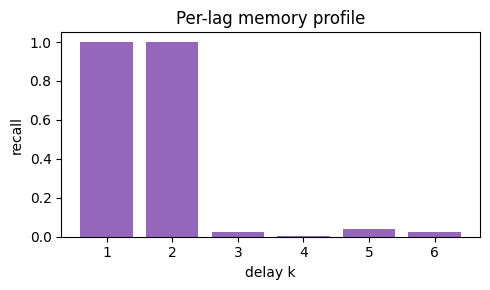

In [10]:
u4, y4 = task_kpauli(140, k=1, seed=3)
X4, _ = qelm_feature_matrix(u4, m_mem, N, SIGMA, BETA, g_use, 'chain', noise=noise)
mc, perk = memory_capacity(X4, u4[m_mem:], k_max=6)
print("total memory capacity (k<=6):", round(mc, 3))
plt.figure(figsize=(5, 3))
plt.bar(range(1, len(perk)+1), perk, color='tab:purple')
plt.xlabel('delay k'); plt.ylabel('recall'); plt.title('Per-lag memory profile')
plt.tight_layout(); plt.show()

## 10 · Run on Quandela Cloud hardware (Belenos)

Swap the **local `Processor`** for a **`RemoteProcessor`** — everything downstream (shadow
features, ridge/MLP head, NRMSE) is unchanged. Get a token from the
[Quandela Cloud](https://cloud.quandela.com) dashboard.

**Shot budgeting from loss.** Valid dual-rail yield is `~η^N`; to obtain `K` valid shots at a
target shadow SNR request `K / η^N` raw samples. Plan `N ≤ 12` for Belenos.

> The exact platform string, available commands and remote-job retrieval are
> version/account dependent — print `available_commands` first and re-confirm names.

In [11]:
TOKEN     = "YOUR_QUANDELA_CLOUD_TOKEN"     # <-- paste your token
PLATFORM  = "qpu:belenos"                    # re-confirm the exact name on your account

def build_remote_reservoir(N, window, sigma, beta, g, topology, token, platform, noise=None):
    remote = pcvl.RemoteProcessor(platform, token=token)
    print("available_commands:", remote.available_commands)   # e.g. ['sample_count','samples']
    if noise is not None:
        remote.noise = noise
    add_input_and_disorder(remote, N, window, sigma, beta)
    add_entangling(remote, N, g, topology)
    remote.min_detected_photons_filter(N)
    remote.with_input(pcvl.BasicState([1, 0] * N))
    return remote

def remote_counts(remote, k_valid=20_000, eta=0.90):
    "Request K/eta^N raw samples so ~k_valid survive post-selection."
    raw = int(k_valid / (eta ** N))
    job = Sampler(remote).sample_count(raw)   # RemoteProcessor -> asynchronous job
    res = job.execute_sync()                  # or: job.get() after polling job.status
    return res['results']

# ---- Uncomment to execute a single reservoir call on hardware ----
# remote = build_remote_reservoir(N, [0.4,0.6,0.2], SIGMA, BETA, g_use, 'chain',
#                                 TOKEN, PLATFORM, noise=default_noise())
# counts = remote_counts(remote, k_valid=20_000, eta=0.90)
# feats  = photon_count_features(counts, N)
# print("hardware feature vector:", np.round(feats, 4))
print("Hardware cell ready — paste a token and uncomment to run on Belenos.")

Hardware cell ready — paste a token and uncomment to run on Belenos.


## 11 · Honest caveats (what does *not* survive the port)

These are lifted straight from your migration plan and are part of the deliverable:

1. **Two-qubit gates are probabilistic.** There is no deterministic per-coupler `CZ^{2g/π}`.
   Route B sidesteps this by using passive mesh mixing (photon-number correlation), so the
   quantity we call "edge of chaos" is *interferometer scrambling*, **not** dual-rail logical
   entanglement. If you need true logical entanglers use `catalog['heralded cz']` and keep
   circuits shallow (Route A, small `N`).
2. **Loss is exponential in photon number** (`~η^N`) and inflates every shadow estimator's
   variance — it is the real scaling limiter, replacing Willow's coherence budget.
3. **Detection may be threshold, not PNR.** Threshold detectors can't tell 1 from 2 photons in
   a mode, biasing photon-count features; Belenos' first 16 modes are PNR-capable — keep data
   modes there.
4. **The Route-C memory is classical.** This demonstrates *memory–processing decoupling* and a
   *quantum feature map*, not a quantum-memory advantage. The quantum-memory claim (sewing,
   collapse-free readout, MC gains) needs the **SPOQC spin** (not generally cloud-exposed on
   Belenos today) or an **optical delay-loop** (`pcvl.TD`, lossy). Flag MCM / feed-forward /
   spin access as *availability risks*, not given facts.
5. **NOON/GHZ metrology (Part 7) is extremely loss-sensitive** — lose one photon and the phase
   information collapses — so the `1/N²` Heisenberg advantage degrades faster than on Willow;
   state the loss threshold explicitly.

All information-theoretic separations from your theory companion transfer intact; only the
platform model (`U(g)`, HOM/BS SWAP test) and the noise budget
`Γ ≈ 1 − η^N·V^(pairs) + p_dark·m` are rewritten in loss terms.